# TSP Solver Benchmark — Gurobi vs Hexaly

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from IPython.display import display
from Gurobi_solver import main as gurobi_main
from Hexaly_solver import main as hexaly_main

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

GUROBI_CSV = 'Gurobi_results.csv'
HEXALY_CSV = 'Hexaly_results.csv'
TIME_LIMIT = 60
INSTANCES_DIR = 'instances'

## 1 · Run Solvers

In [2]:
print('Running Gurobi solver...')
gurobi_main(instances_dir=INSTANCES_DIR, time_limit=TIME_LIMIT, output_csv=GUROBI_CSV)

print('Running Hexaly solver...')
hexaly_main(instances_dir=INSTANCES_DIR, time_limit=TIME_LIMIT, output_csv=HEXALY_CSV)

print('\n✅ Both solvers finished.')

Running Gurobi solver...
Found 10 instance(s) in 'instances/'

Instance                          N       Obj Value     Gap    Load   Build   Solve   Total Status      
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2713610
Academic license 2713610 - for non-commercial use only - registered to 44___@std.psau.edu.sa
  d2103                        2103            0.00   0.00%    4.8s   25.2s    9.4s   39.4s  OPTIMAL     
  dsj1000                      1000            0.00   0.00%    1.2s    5.2s    1.8s    8.2s  OPTIMAL     
  fl3795                       3795            0.00   0.00%   16.1s   86.1s   37.2s  139.3s  OPTIMAL     
  fnl4461                      4461             N/A     N/A   22.9s  119.7s   65.0s  207.6s  NO_SOLUTION 
  pcb1173                      1173            0.00   0.00%    1.6s    7.5s    2.5s   11.6s  OPTIMAL     
  pcb3038                      3038            0.00   0.00%   10.7s   55.4s   23.9s   90.0s  OPTIMAL     
  pla7397   

## 2 · Load Results

In [4]:
gurobi_df = pd.read_csv(GUROBI_CSV)
hexaly_df  = pd.read_csv(HEXALY_CSV)

def to_numeric(df, cols):
    for col in cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        gurobi_df['gap_pct'] = gurobi_df['gap_pct'].fillna(100)
        hexaly_df['gap_pct']  = hexaly_df['gap_pct'].fillna(100)

numeric_cols = ['nodes', 'gap_pct', 'load_time_s', 'build_time_s', 'solve_time_s', 'total_time_s']
to_numeric(gurobi_df, numeric_cols)
to_numeric(hexaly_df, numeric_cols)

print(f'Gurobi  — {len(gurobi_df)} instance(s)')
print(f'Hexaly  — {len(hexaly_df)} instance(s)')

Gurobi  — 10 instance(s)
Hexaly  — 10 instance(s)


## 3 · Side-by-Side Comparison Table

In [5]:
merged = gurobi_df[['instance', 'nodes', 'gap_pct', 'solve_time_s', 'total_time_s', 'status']].merge(
    hexaly_df[['instance', 'gap_pct', 'solve_time_s', 'total_time_s', 'status']],
    on='instance', suffixes=('_gurobi', '_hexaly')
)
merged = merged.sort_values('nodes').reset_index(drop=True)

merged.columns = [
    'Instance', 'Nodes',
    'Gurobi Gap%', 'Gurobi Solve(s)', 'Gurobi Total(s)', 'Gurobi Status',
    'Hexaly Gap%', 'Hexaly Solve(s)', 'Hexaly Total(s)', 'Hexaly Status'
]

STATUS_COLORS = {
    'OPTIMAL':    'background-color: #d4edda; color: #155724',
    'TIME_LIMIT': 'background-color: #fff3cd; color: #856404',
    'SOLVED':     'background-color: #cce5ff; color: #004085',
    'NO_SOLUTION':'background-color: #f8d7da; color: #721c24',
    'N/A':        'background-color: #f8d7da; color: #721c24',
    'LOAD_ERROR': 'background-color: #f8d7da; color: #721c24',
}

def style_status(val):
    return STATUS_COLORS.get(str(val), '')

def highlight_better_gap(row):
    styles = [''] * len(row)
    g = pd.to_numeric(row.get('Gurobi Gap%', None), errors='coerce')
    h = pd.to_numeric(row.get('Hexaly Gap%', None), errors='coerce')
    gi = row.index.get_loc('Gurobi Gap%')
    hi = row.index.get_loc('Hexaly Gap%')
    if pd.notna(g) and pd.notna(h):
        if g < h:
            styles[gi] = 'background-color: #d4edda; color: #155724'
        elif h < g:
            styles[hi] = 'background-color: #d4edda; color: #155724'
    return styles

styled = (
    merged.style
    .map(style_status, subset=['Gurobi Status', 'Hexaly Status'])
    .apply(highlight_better_gap, axis=1)
    .format({
        'Gurobi Gap%':    lambda x: f'{x:.2f}%' if pd.notna(x) else 'N/A',
        'Hexaly Gap%':    lambda x: f'{x:.2f}%' if pd.notna(x) else 'N/A',
        'Gurobi Solve(s)':lambda x: f'{x:.1f}s' if pd.notna(x) else 'N/A',
        'Hexaly Solve(s)':lambda x: f'{x:.1f}s' if pd.notna(x) else 'N/A',
        'Gurobi Total(s)':lambda x: f'{x:.1f}s' if pd.notna(x) else 'N/A',
        'Hexaly Total(s)':lambda x: f'{x:.1f}s' if pd.notna(x) else 'N/A',
    })
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2c3e50'), ('color', 'white'),
                  ('font-size', '12px'), ('text-align', 'center'), ('padding', '8px')]
    }, {
        'selector': 'td',
        'props': [('text-align', 'center'), ('padding', '6px'), ('font-size', '12px')]
    }])
    .set_caption('🏁 Gurobi vs Hexaly — TSP Benchmark Results')
)

display(styled)

,Instance,Nodes,Gurobi Gap%,Gurobi Solve(s),Gurobi Total(s),Gurobi Status,Hexaly Gap%,Hexaly Solve(s),Hexaly Total(s),Hexaly Status
0,dsj1000,1000,0.00%,1.8s,8.2s,OPTIMAL,1.51%,59.3s,61.8s,SOLVED
1,pcb1173,1173,0.00%,2.5s,11.6s,OPTIMAL,1.15%,59.8s,62.7s,SOLVED
2,d2103,2103,0.00%,9.4s,39.4s,OPTIMAL,1.80%,59.9s,65.5s,SOLVED
3,pr2392,2392,0.00%,12.3s,49.9s,OPTIMAL,1.92%,59.4s,66.8s,SOLVED
4,pcb3038,3038,0.00%,23.9s,90.0s,OPTIMAL,1.90%,59.7s,71.8s,SOLVED
5,fl3795,3795,0.00%,37.2s,139.3s,OPTIMAL,5.02%,59.4s,77.8s,SOLVED
6,fnl4461,4461,100.00%,65.0s,207.6s,NO_SOLUTION,1.81%,60.3s,86.2s,SOLVED
7,rl5915,5915,100.00%,127.0s,383.1s,NO_SOLUTION,3.90%,59.4s,103.1s,SOLVED
8,rl5934,5934,100.00%,116.1s,375.7s,NO_SOLUTION,3.66%,59.3s,103.7s,SOLVED
9,pla7397,7397,100.00%,72.7s,537.8s,NO_SOLUTION,2.63%,60.0s,132.9s,SOLVED


## 4 · Solve Time Comparison

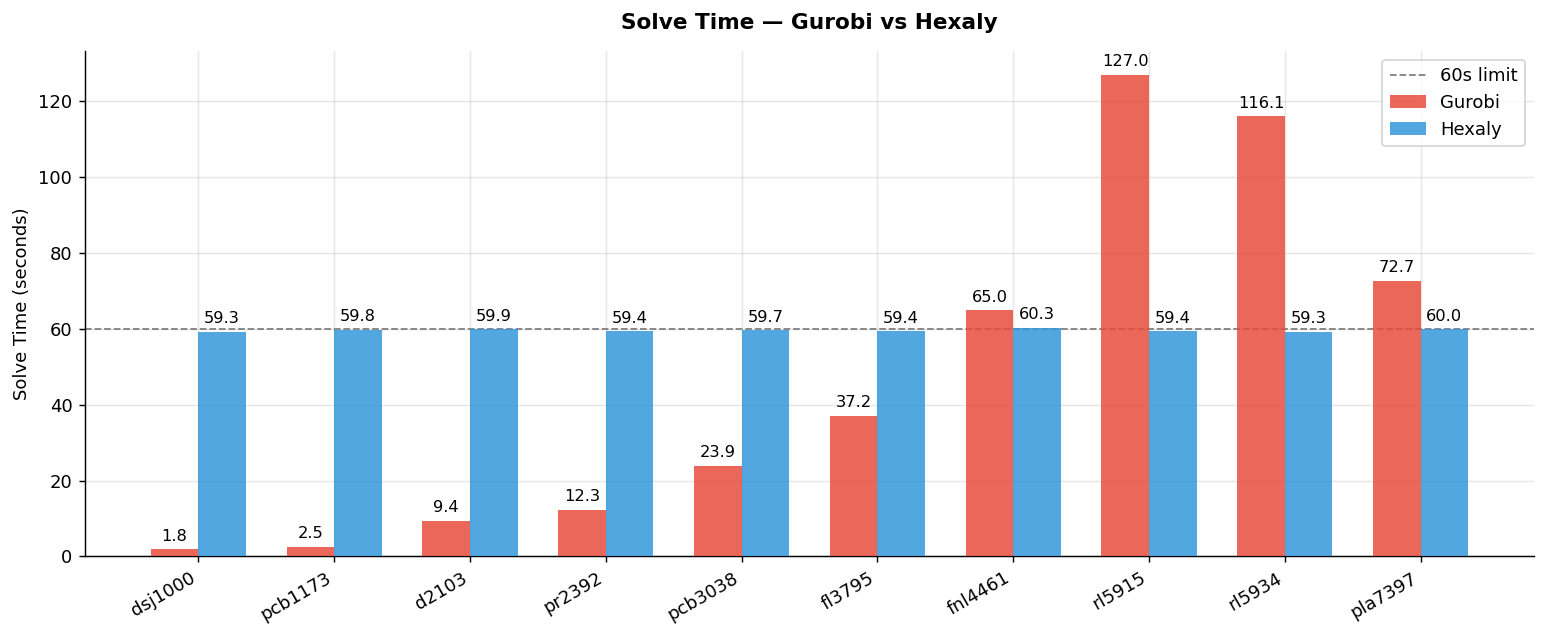

In [6]:
instances = merged['Instance'].tolist()
x = np.arange(len(instances))
width = 0.35

fig, ax = plt.subplots(figsize=(max(8, len(instances) * 1.2), 5))

bars_g = ax.bar(x - width/2, pd.to_numeric(merged['Gurobi Solve(s)'], errors='coerce'),
                width, label='Gurobi', color='#e74c3c', alpha=0.85, zorder=3)
bars_h = ax.bar(x + width/2, pd.to_numeric(merged['Hexaly Solve(s)'], errors='coerce'),
                width, label='Hexaly', color='#3498db', alpha=0.85, zorder=3)

ax.bar_label(bars_g, fmt='%.1f', padding=3, fontsize=9)
ax.bar_label(bars_h, fmt='%.1f', padding=3, fontsize=9)

ax.axhline(TIME_LIMIT, color='gray', linestyle='--', linewidth=1, label=f'{TIME_LIMIT}s limit')
ax.set_xticks(x)
ax.set_xticklabels(instances, rotation=30, ha='right')
ax.set_ylabel('Solve Time (seconds)')
ax.set_title('Solve Time — Gurobi vs Hexaly', fontweight='bold', pad=12)
ax.legend()
plt.tight_layout()
plt.savefig('plots/plot_solve_time.png', bbox_inches='tight')
plt.show()

## 5 · Total Time (Load + Build + Solve)

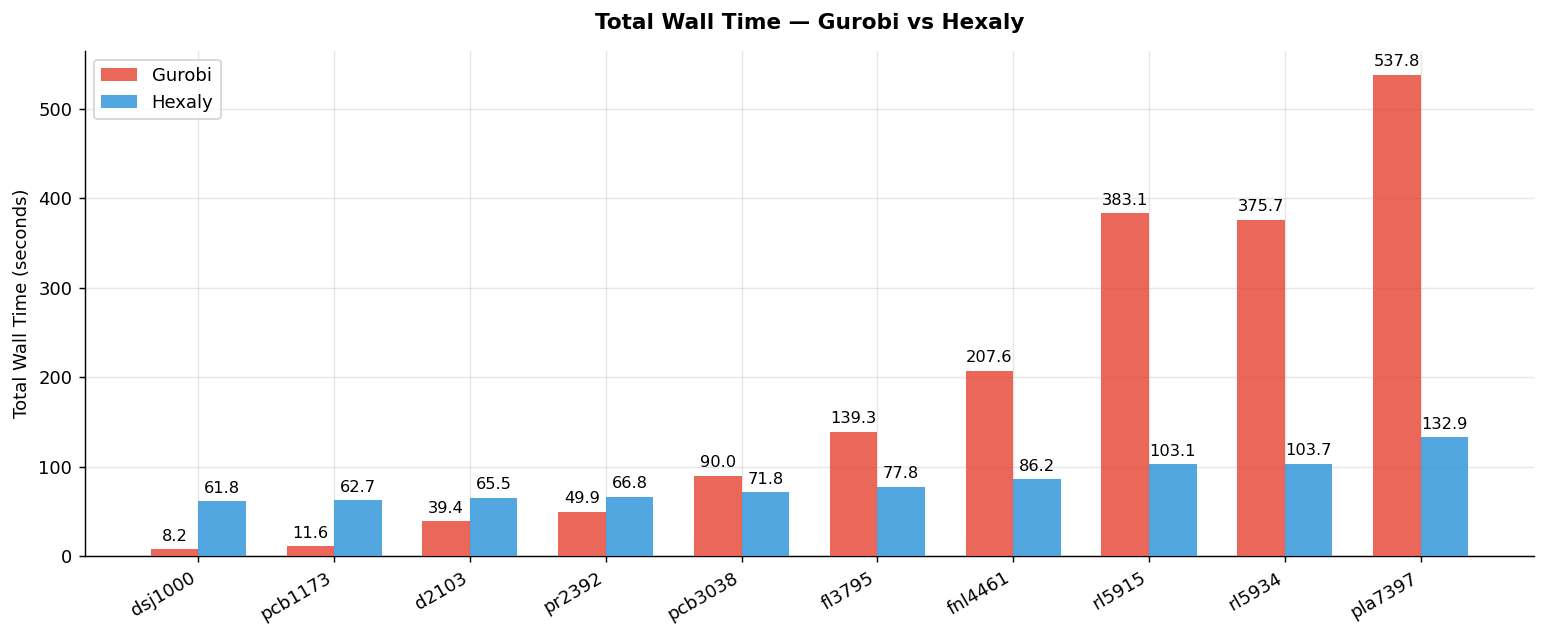

In [7]:
fig, ax = plt.subplots(figsize=(max(8, len(instances) * 1.2), 5))

bars_g = ax.bar(x - width/2, pd.to_numeric(merged['Gurobi Total(s)'], errors='coerce'),
                width, label='Gurobi', color='#e74c3c', alpha=0.85, zorder=3)
bars_h = ax.bar(x + width/2, pd.to_numeric(merged['Hexaly Total(s)'], errors='coerce'),
                width, label='Hexaly', color='#3498db', alpha=0.85, zorder=3)

ax.bar_label(bars_g, fmt='%.1f', padding=3, fontsize=9)
ax.bar_label(bars_h, fmt='%.1f', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(instances, rotation=30, ha='right')
ax.set_ylabel('Total Wall Time (seconds)')
ax.set_title('Total Wall Time — Gurobi vs Hexaly', fontweight='bold', pad=12)
ax.legend()
plt.tight_layout()
plt.savefig('plots/plot_total_time.png', bbox_inches='tight')
plt.show()

## 6 · Optimality Gap Comparison

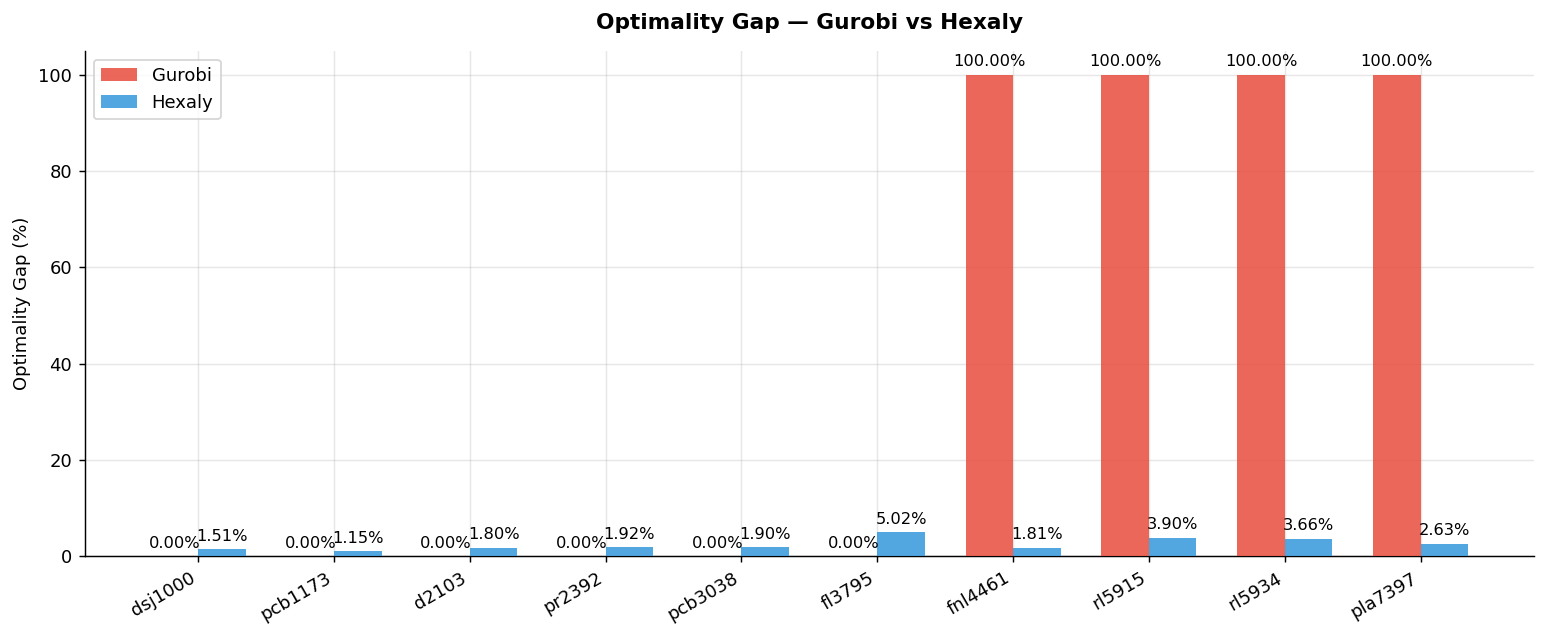

In [8]:
fig, ax = plt.subplots(figsize=(max(8, len(instances) * 1.2), 5))

bars_g = ax.bar(x - width/2, pd.to_numeric(merged['Gurobi Gap%'], errors='coerce'),
                width, label='Gurobi', color='#e74c3c', alpha=0.85, zorder=3)
bars_h = ax.bar(x + width/2, pd.to_numeric(merged['Hexaly Gap%'], errors='coerce'),
                width, label='Hexaly', color='#3498db', alpha=0.85, zorder=3)

ax.bar_label(bars_g, fmt='%.2f%%', padding=3, fontsize=9)
ax.bar_label(bars_h, fmt='%.2f%%', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(instances, rotation=30, ha='right')
ax.set_ylabel('Optimality Gap (%)')
ax.set_title('Optimality Gap — Gurobi vs Hexaly', fontweight='bold', pad=12)
ax.legend()
plt.tight_layout()
plt.savefig('plots/plot_gap.png', bbox_inches='tight')
plt.show()

## 7 · Time Breakdown — Load / Build / Solve (Stacked)

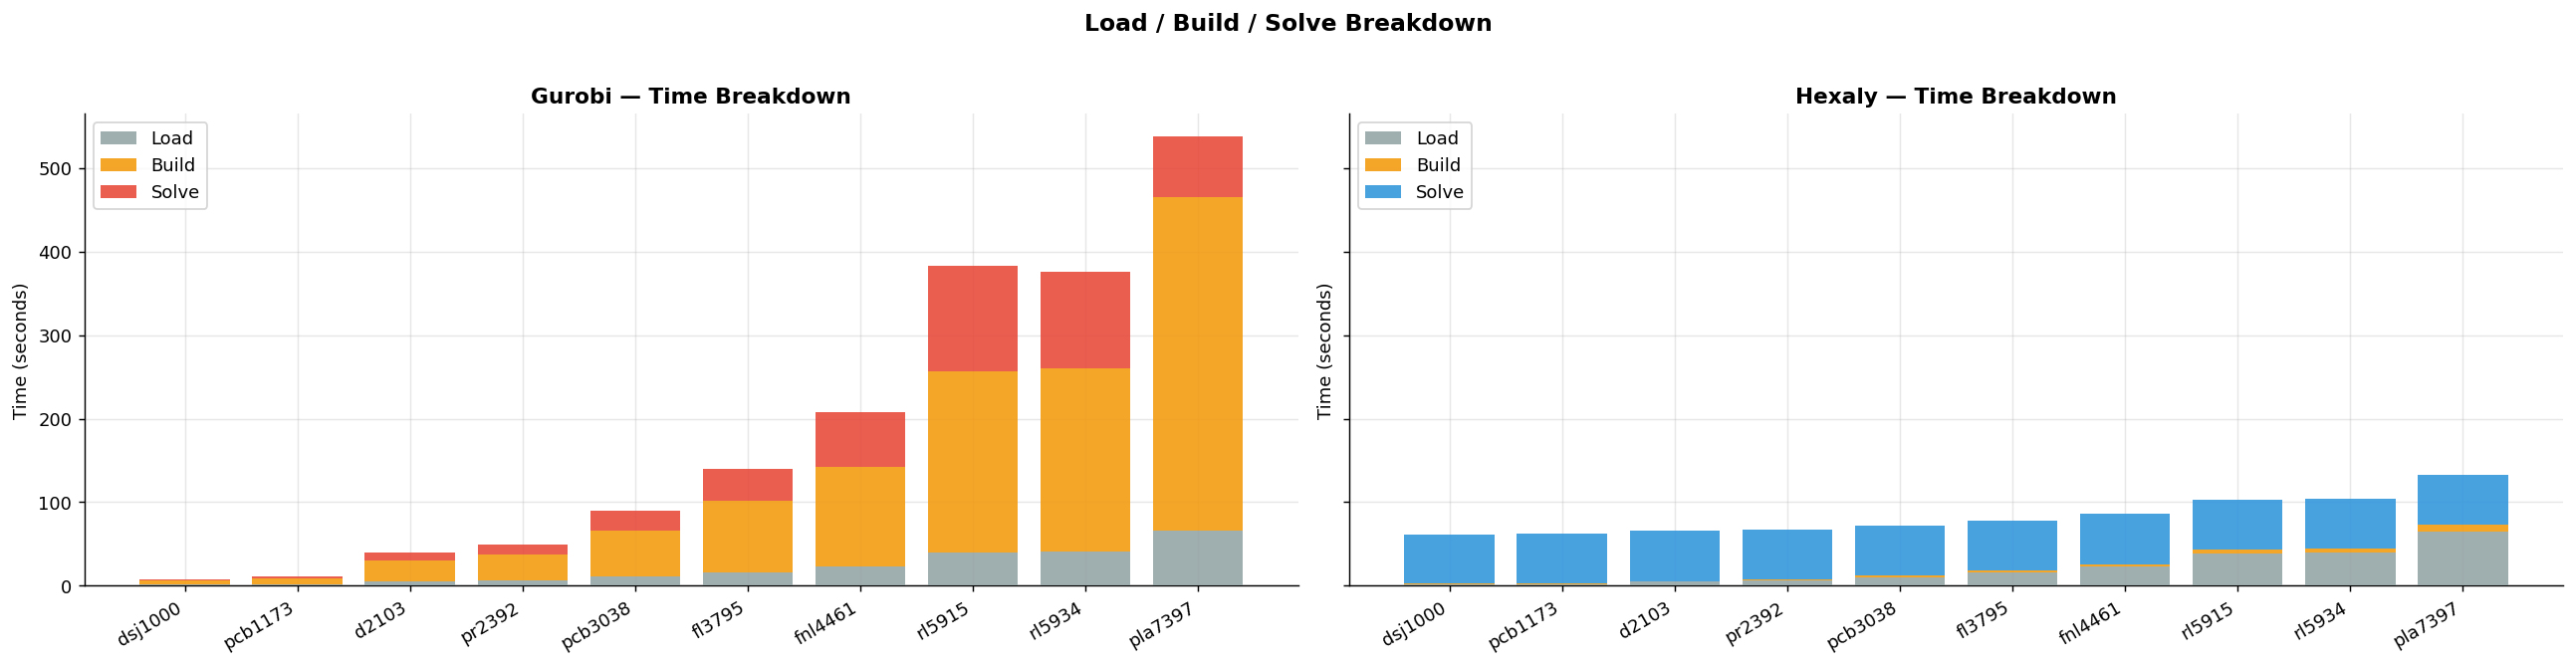

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(max(12, len(instances) * 2), 5), sharey=True)

gurobi_df = gurobi_df.sort_values('nodes').reset_index(drop=True)
hexaly_df = hexaly_df.sort_values('nodes').reset_index(drop=True)
solvers = [
    ('Gurobi', gurobi_df, axes[0], '#e74c3c'),
    ('Hexaly', hexaly_df, axes[1], '#3498db'),
]

for name, df, ax, base_color in solvers:
    inst  = df['instance'].tolist()
    xi    = np.arange(len(inst))
    load  = pd.to_numeric(df['load_time_s'],  errors='coerce').fillna(0)
    build = pd.to_numeric(df['build_time_s'], errors='coerce').fillna(0)
    solve = pd.to_numeric(df['solve_time_s'], errors='coerce').fillna(0)

    ax.bar(xi, load,  label='Load',  color='#95a5a6', alpha=0.9, zorder=3)
    ax.bar(xi, build, label='Build', color='#f39c12', alpha=0.9, bottom=load, zorder=3)
    ax.bar(xi, solve, label='Solve', color=base_color, alpha=0.9, bottom=load + build, zorder=3)

    ax.set_xticks(xi)
    ax.set_xticklabels(inst, rotation=30, ha='right')
    ax.set_title(f'{name} — Time Breakdown', fontweight='bold')
    ax.set_ylabel('Time (seconds)')
    ax.legend(loc='upper left')

plt.suptitle('Load / Build / Solve Breakdown', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/plot_time_breakdown.png', bbox_inches='tight')
plt.show()

## 8 · Nodes vs Solve Time (Scalability)

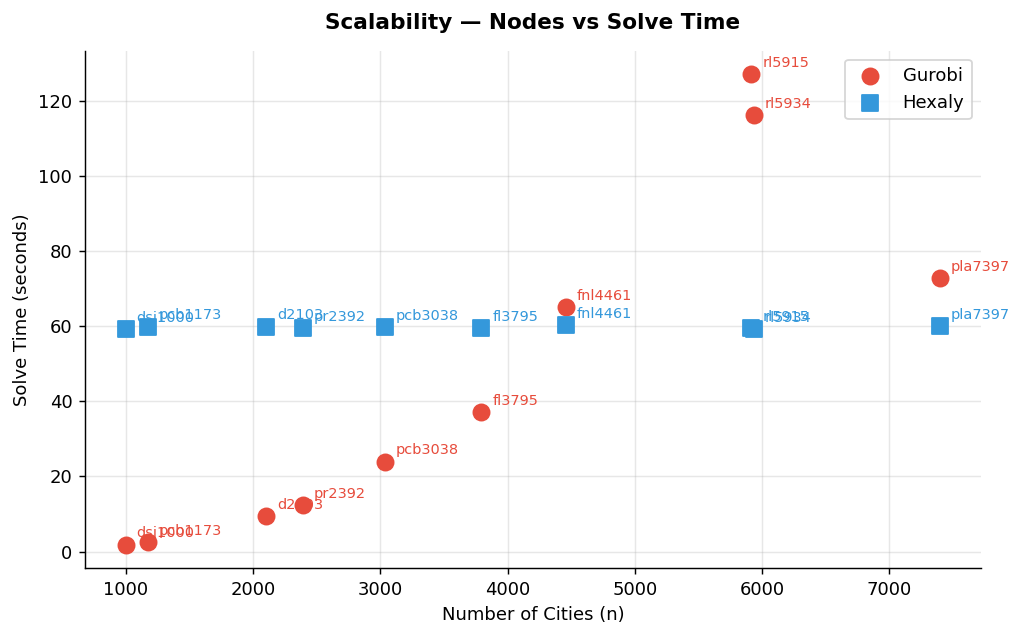

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

for df, label, color, marker in [
    (gurobi_df, 'Gurobi', '#e74c3c', 'o'),
    (hexaly_df, 'Hexaly', '#3498db', 's'),
]:
    nodes = pd.to_numeric(df['nodes'], errors='coerce')
    solve = pd.to_numeric(df['solve_time_s'], errors='coerce')
    mask  = nodes.notna() & solve.notna()
    ax.scatter(nodes[mask], solve[mask], label=label, color=color,
               marker=marker, s=80, zorder=4)
    for _, row in df[mask].iterrows():
        ax.annotate(row['instance'],
                    (pd.to_numeric(row['nodes']), pd.to_numeric(row['solve_time_s'])),
                    textcoords='offset points', xytext=(6, 4), fontsize=8, color=color)

ax.set_xlabel('Number of Cities (n)')
ax.set_ylabel('Solve Time (seconds)')
ax.set_title('Scalability — Nodes vs Solve Time', fontweight='bold', pad=12)
ax.legend()
plt.tight_layout()
plt.savefig('plots/plot_scalability.png', bbox_inches='tight')
plt.show()

## 9 · Statistics

In [12]:
def gap_stats(series, name):
    s = series.dropna()
    return pd.Series({
        'Solver': name,
        'Median Gap': s.median(),
        'Std Gap': s.std(),
        'Min Gap': s.min(),
        'Max Gap': s.max(),
        'Mean Gap': s.mean(),
    })

gurobi_gap = gurobi_df['gap_pct']
hexaly_gap  = hexaly_df['gap_pct']

stats_df = pd.DataFrame([
    gap_stats(gurobi_gap, 'Gurobi'),
    gap_stats(hexaly_gap,  'Hexaly'),
])

stats_styled = (
    stats_df.style
    .format({
        'Median Gap': '{:.2f}%',
        'Std Gap': '{:.2f}%',
        'Min Gap': '{:.2f}%',
        'Max Gap': '{:.2f}%',
        'Mean Gap': '{:.2f}%',
    })
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2c3e50'), ('color', 'white'),
                  ('font-size', '12px'), ('text-align', 'center'), ('padding', '8px')]
    }, {
        'selector': 'td',
        'props': [('text-align', 'center'), ('padding', '6px'), ('font-size', '12px')]
    }])
    .set_caption('Gap Statistics — Gurobi vs Hexaly')
    .hide(axis='index')
)

display(stats_styled)


Solver,Median Gap,Std Gap,Min Gap,Max Gap,Mean Gap
Gurobi,0.00%,51.64%,0.00%,100.00%,40.00%
Hexaly,1.91%,1.25%,1.15%,5.02%,2.53%
